In [1]:
import pandas as pd

# This is the standard URL for the Hotel Bookings dataset
url = "https://raw.githubusercontent.com/rfordatascience/tidytuesday/master/data/2020/2020-02-11/hotels.csv"

# Fetching the data
try:
    hotel_data = pd.read_csv(url)
    print(f"Dataset loaded successfully!")
    print(f"Rows: {hotel_data.shape[0]}, Columns: {hotel_data.shape[1]}")
except Exception as e:
    print(f"Error loading data: {e}")

# Quick look at the 32 columns
print(hotel_data.columns)

Dataset loaded successfully!
Rows: 119390, Columns: 32
Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date'],
      dtype='object')


In [2]:
import pandas as pd
import numpy as np
import pytimetk as tk
from missingno import matrix

# Modeling
import statsmodels.api as sm
from statsmodels.genmod.generalized_linear_model import GLM
from statsmodels.genmod.families import Binomial
from statsmodels.genmod.families.links import logit
from sklearn.metrics import roc_auc_score


In [6]:
# 0.0 DATA ----
hotel_cancellations_raw_df = hotel_data.copy()
df= hotel_data.copy()

In [10]:
pd.options.display.max_columns= None
hotel_cancellations_raw_df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [ ]:
# How many people cancel?
cancellation_counts = hotel_cancellations_raw_df['is_canceled'].value_counts().reset_index()
cancellation_counts.columns = ['is_canceled', 'n']
cancellation_counts['prop'] = cancellation_counts['n'] / cancellation_counts['n'].sum()

# Display the result
print(cancellation_counts)


   is_canceled      n      prop
0            0  75166  0.629584
1            1  44224  0.370416


In [24]:
a,b= 'stays_in_weekend_nights','stays_in_week_nights'
df['night_spent']= df[a]+df[b]
cost= ((df.loc[df['is_canceled']== 1, 'adr']) * df['night_spent']).sum().round(2)
formatted_cost = "${:,.0f}".format(cost)
print(f"Total Cost: {formatted_cost}")

Total Cost: $16,727,237


In [25]:
# # How much does this cost the hotel?
# # Example calculation based on 44,224 cancellations, 0 avg room rate, and 3.4 nights avg stay
# cost = 44224 * 200 * 3.4
# formatted_cost = "${:,.0f}".format(cost)
# print(f"Total Cost: {formatted_cost}")


In [26]:

# 10% of the cost
ten_percent_cost = 0.1 * cost
formatted_ten_percent_cost = "${:,.0f}".format(ten_percent_cost)
print(f"10% Savings Potential: {formatted_ten_percent_cost}")


10% Savings Potential: $1,672,724


In [27]:

# 1.0 DATA PROCESSING ----

# Basic Feature Engineering
hotel_cancellations_df = hotel_cancellations_raw_df.copy()

# Adding new features
hotel_cancellations_df['total_stay'] = (
    hotel_cancellations_df['stays_in_weekend_nights'] + 
    hotel_cancellations_df['stays_in_week_nights']
)

hotel_cancellations_df['total_guests'] = (
    hotel_cancellations_df['adults'] + 
    hotel_cancellations_df['children'] + 
    hotel_cancellations_df['babies']
)

hotel_cancellations_df['different_room_assigned'] = (
    hotel_cancellations_df['reserved_room_type'] != 
    hotel_cancellations_df['assigned_room_type']
).astype(int)

# Dropping the original columns
hotel_cancellations_df.drop(
    columns=[
        'stays_in_weekend_nights', 'stays_in_week_nights',
        'adults', 'children', 'babies',
        'reserved_room_type', 'assigned_room_type'
    ],
    inplace=True
)


<Axes: >

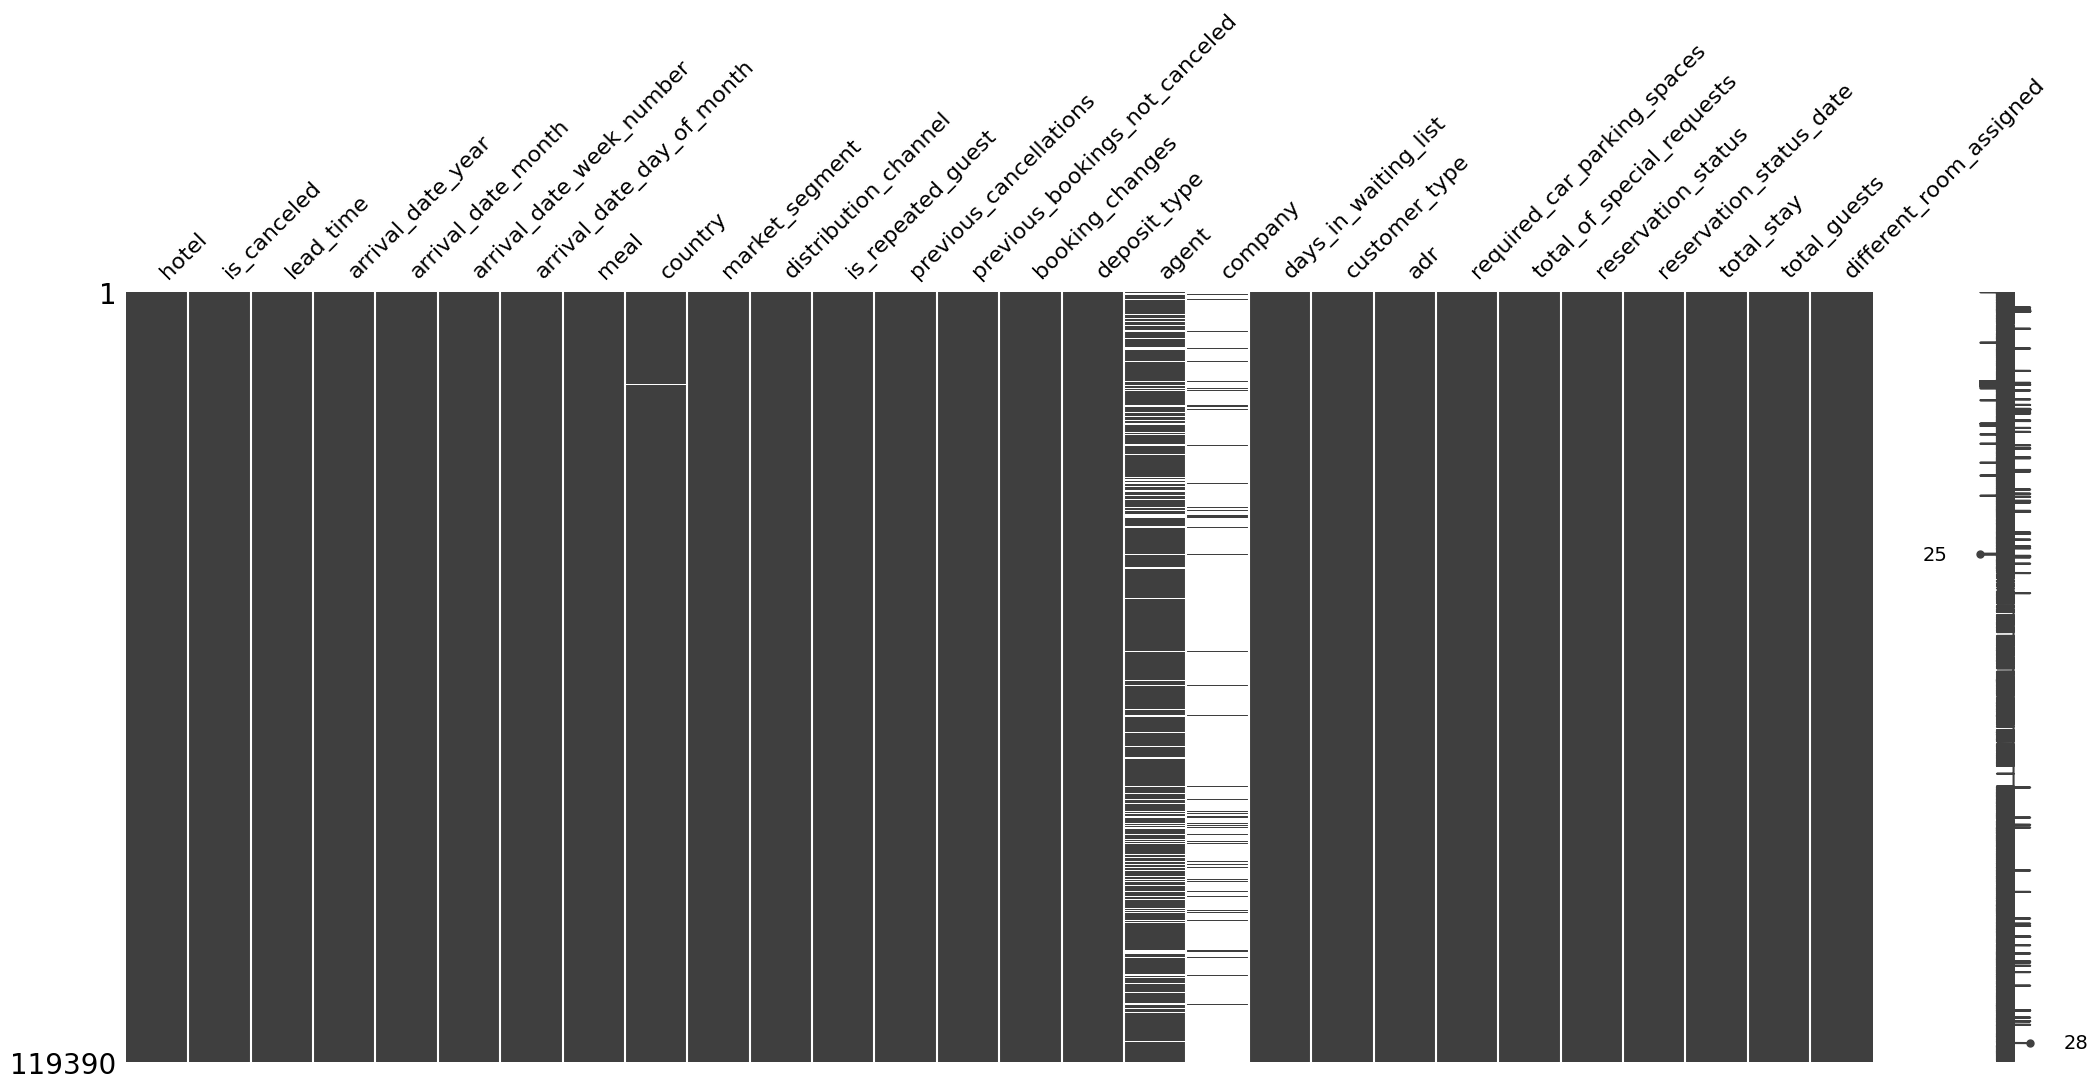

In [28]:
# Fix Missing
# Plot missing values
matrix(hotel_cancellations_df)

In [31]:

# Fix missing values and drop columns
hotel_cancellations_df = hotel_cancellations_df.drop(columns=['company', 'agent'])
hotel_cancellations_df['country'] = hotel_cancellations_df['country'].fillna('PRT')
hotel_cancellations_df.dropna(inplace=True)

# Drop Unneeded Columns
hotel_cancellations_df.drop(columns=['reservation_status_date'], inplace=True)

# Save cleaned data
hotel_cancellations_df.to_csv("data_hotel_cancellations_clean.csv", index=False)


In [33]:

# 2.0 CORRELATION (LEVEL 1: ASSOCIATION) ----
# Reload cleaned data
hotel_cancellations_df = pd.read_csv("data_hotel_cancellations_clean.csv")

# Binarize and Correlate using pytimetk
df_binarized = hotel_cancellations_df.binarize()
df_correlated = df_binarized.correlate(target="is_canceled__1")

# Visualize
df_correlated.plot_correlation_funnel()


In [35]:

# 3.0 SUBSET FEATURES ----
hotel_cancellations_subset_df = hotel_cancellations_df.drop(columns=['reservation_status'])

# Selecting specific columns for the system model
hotel_cancellations_subset_df = hotel_cancellations_subset_df[[
    'is_canceled', 'deposit_type', 'country', 'previous_cancellations',
    'lead_time', 'different_room_assigned',
    'market_segment', 'required_car_parking_spaces', 'distribution_channel',
    'hotel', 'customer_type', 'previous_bookings_not_canceled', 'is_repeated_guest'
]]

# Creating dummies for 'country'
hotel_cancellations_subset_df['country_PRT'] = (hotel_cancellations_subset_df['country'] == 'PRT').astype(int)
hotel_cancellations_subset_df['country_other'] = (hotel_cancellations_subset_df['country'] != 'PRT').astype(int)
hotel_cancellations_subset_df.drop(columns=['country'], inplace=True)


In [ ]:
# , 'total_special_requests'

In [36]:

# 4.0 CAUSAL HYPOTHESIS ----

# Simple Logistic Model: Does Lead Time affect cancellations?
lead_time_df = hotel_cancellations_subset_df[['is_canceled', 'lead_time']].copy()
lead_time_df['lead_time_binned'] = pd.qcut(lead_time_df['lead_time'], q=4, duplicates='drop')

# One-hot encoding
lead_time_dummies = pd.get_dummies(lead_time_df['lead_time_binned'], drop_first=True)

X = sm.add_constant(lead_time_dummies.astype(float))
y = lead_time_df['is_canceled'].astype(float)

logit_model = sm.Logit(y, X)
result = logit_model.fit()
print(result.summary())


Optimization terminated successfully.
         Current function value: 0.608661
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:            is_canceled   No. Observations:               119386
Model:                          Logit   Df Residuals:                   119382
Method:                           MLE   Df Model:                            3
Date:                Mon, 16 Feb 2026   Pseudo R-squ.:                 0.07662
Time:                        16:05:59   Log-Likelihood:                -72666.
converged:                       True   LL-Null:                       -78695.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const             -1.7643      0.016   -108.441      0.000      -1.796      -1.732
(18.0, 69.0]     

In [ ]:

# Interpreting Odds (from screenshot notes)
# np.exp(1.98) -> 160+ days lead time results in ~7.2X risk of cancellation

# 5.0 CONSIDERING CONFOUNDERS ----
df = hotel_cancellations_subset_df.copy()
df['lead_time'] = pd.qcut(df['lead_time'], q=4, duplicates='drop')
df = pd.get_dummies(df, drop_first=True)

# Convert bools to int
for column in df.columns:
    if df[column].dtype == 'bool':
        df[column] = df[column].astype(int)

# Train/Test Split
train_df = df.sample(frac=0.8, random_state=123)
test_df = df.drop(train_df.index)

# Fit Model with L1 Penalty (Lasso)
X_train = sm.add_constant(train_df.drop(columns=['is_canceled']))
y_train = train_df['is_canceled']

model = GLM(y_train, X_train, family=Binomial(), link=logit())
# alpha=0.01 and L1_wt=1.0 for Lasso
result = model.fit_regularized(method='elastic_net', alpha=0.01, L1_wt=1.0)

# Evaluate
X_test = sm.add_constant(test_df.drop(columns=['is_canceled']))
y_test = test_df['is_canceled']

predicted_probabilities = result.predict(X_test)
roc_auc = roc_auc_score(y_test, predicted_probabilities)
print(f"ROC AUC Score: {roc_auc}")

# Causal Interpretation (Pre-treatment effect)
# np.exp(0.40) -> ~1.5X risk of cancellation for each additional lead time bin when controlling for confounders